# Exploracion de datos sinteticos

Genera y visualiza el modo normal y cada uno de los 4 escenarios de anomalia producidos por `predictive_monitoring_tool.data.generator.generate()`, para inspeccion visual rapida. Cada celda produce un grafico de la(s) metrica(s) relevante(s) a lo largo del tiempo, con la ventana de anomalia resaltada (`axvspan`) cuando aplica.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from predictive_monitoring_tool.data.generator import generate

DURATION_MINUTES = 180
SEED = 42


## Modo normal

Sin escenario de anomalia (`scenario=None`).

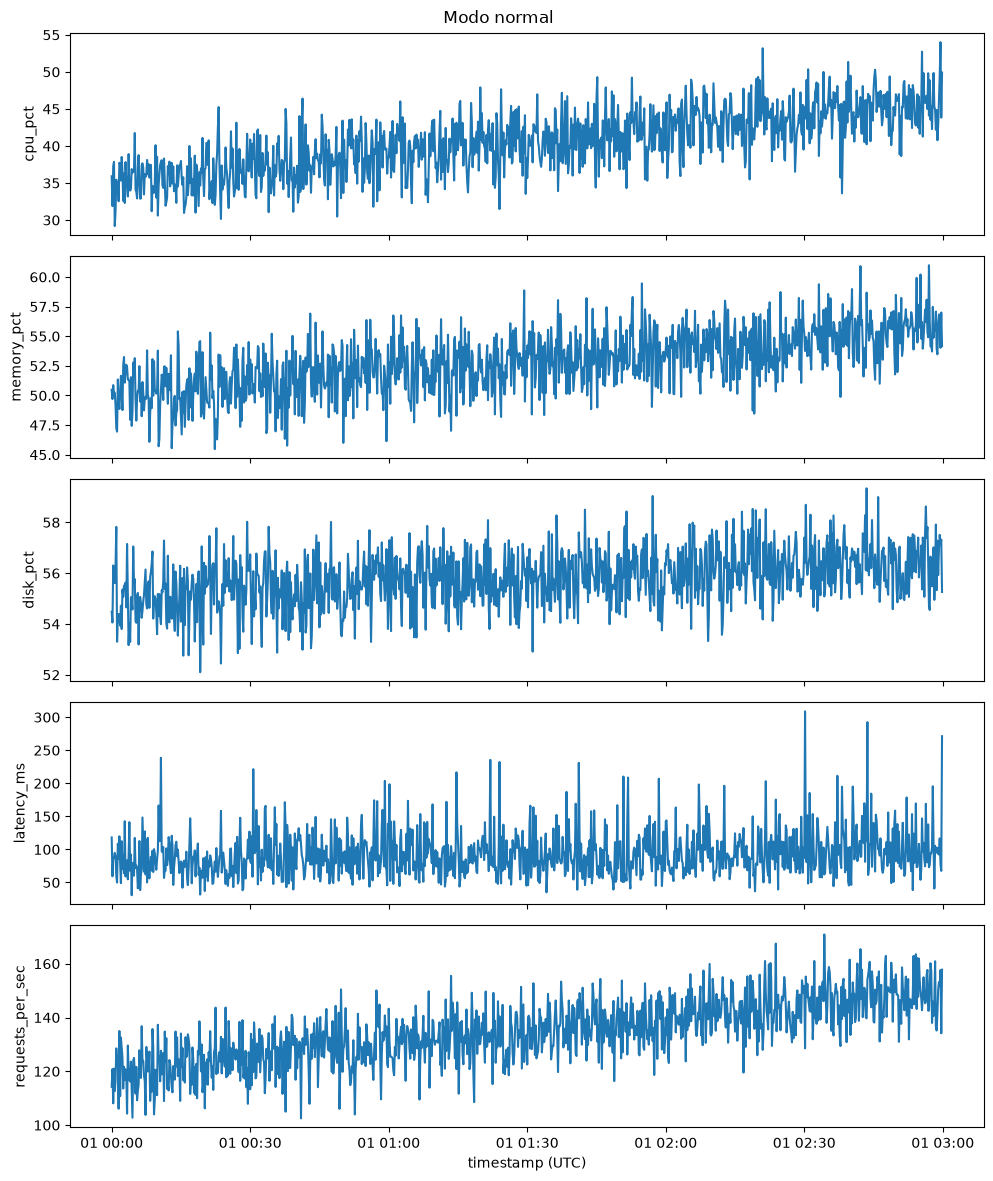

In [2]:
df_normal = generate(DURATION_MINUTES, seed=SEED)

fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=True)
for ax, column in zip(axes, df_normal.columns):
    ax.plot(df_normal.index, df_normal[column])
    ax.set_ylabel(column)
axes[-1].set_xlabel("timestamp (UTC)")
fig.suptitle("Modo normal")
fig.tight_layout()
plt.show()


## Escenario: `memory_leak`

`memory_pct` sube de forma monotona (no decreciente) dentro de la ventana.

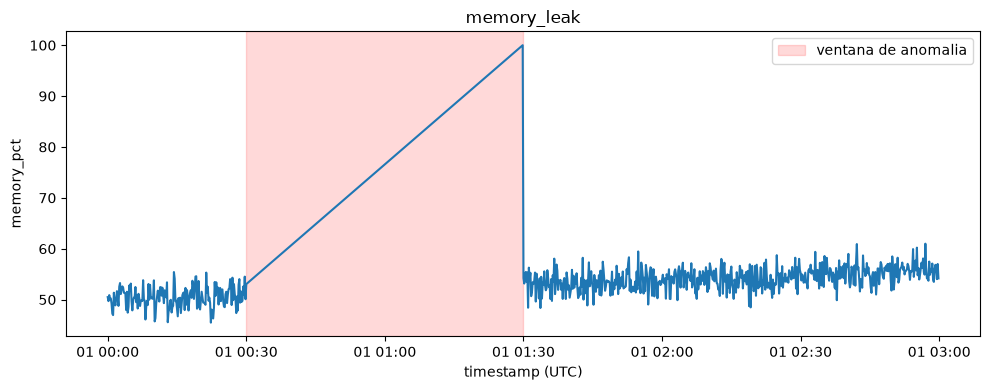

In [3]:
start_minute, window_minutes = 30, 60
df_memory_leak = generate(
    DURATION_MINUTES,
    scenario="memory_leak",
    scenario_start_minute=start_minute,
    anomaly_duration_minutes=window_minutes,
    seed=SEED,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_memory_leak.index, df_memory_leak["memory_pct"])
ax.axvspan(
    df_memory_leak.index[0] + pd.Timedelta(minutes=start_minute),
    df_memory_leak.index[0] + pd.Timedelta(minutes=start_minute + window_minutes),
    color="red", alpha=0.15, label="ventana de anomalia",
)
ax.set_ylabel("memory_pct")
ax.set_xlabel("timestamp (UTC)")
ax.set_title("memory_leak")
ax.legend()
fig.tight_layout()
plt.show()


## Escenario: `cpu_spike`

`cpu_pct` sube abruptamente muy por encima de la linea base dentro de la ventana.

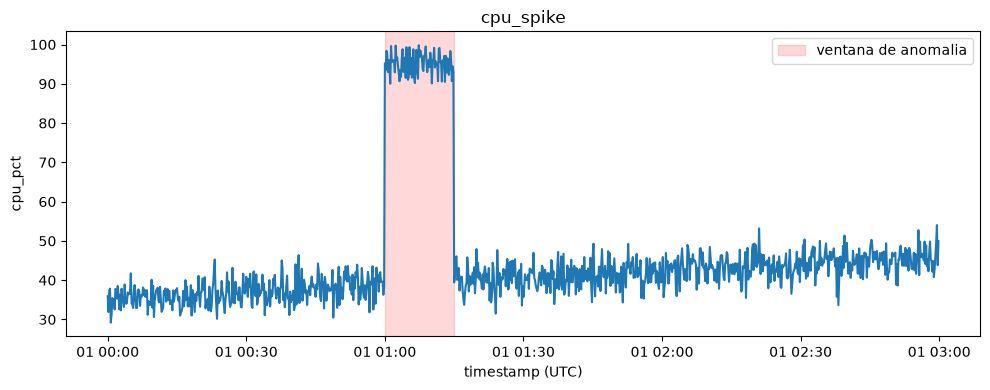

In [4]:
start_minute, window_minutes = 60, 15
df_cpu_spike = generate(
    DURATION_MINUTES,
    scenario="cpu_spike",
    scenario_start_minute=start_minute,
    anomaly_duration_minutes=window_minutes,
    seed=SEED,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_cpu_spike.index, df_cpu_spike["cpu_pct"])
ax.axvspan(
    df_cpu_spike.index[0] + pd.Timedelta(minutes=start_minute),
    df_cpu_spike.index[0] + pd.Timedelta(minutes=start_minute + window_minutes),
    color="red", alpha=0.15, label="ventana de anomalia",
)
ax.set_ylabel("cpu_pct")
ax.set_xlabel("timestamp (UTC)")
ax.set_title("cpu_spike")
ax.legend()
fig.tight_layout()
plt.show()


## Escenario: `disk_fill`

`disk_pct` se acumula de forma monotona (no decreciente) dentro de la ventana, sin meseta.

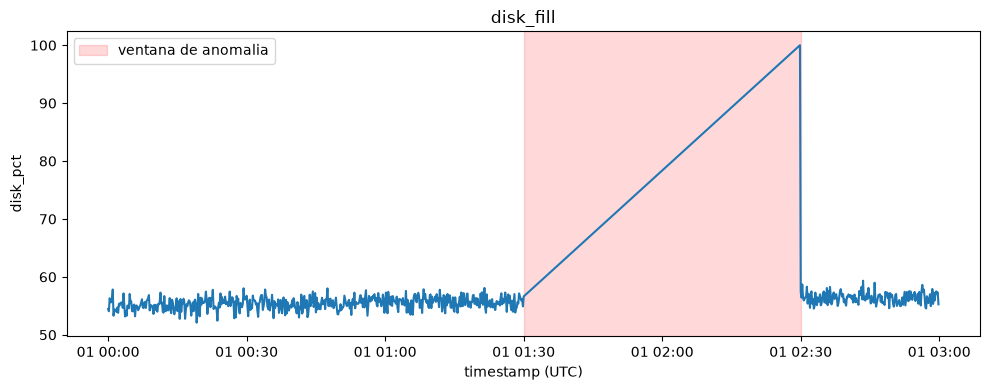

In [5]:
start_minute, window_minutes = 90, 60
df_disk_fill = generate(
    DURATION_MINUTES,
    scenario="disk_fill",
    scenario_start_minute=start_minute,
    anomaly_duration_minutes=window_minutes,
    seed=SEED,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_disk_fill.index, df_disk_fill["disk_pct"])
ax.axvspan(
    df_disk_fill.index[0] + pd.Timedelta(minutes=start_minute),
    df_disk_fill.index[0] + pd.Timedelta(minutes=start_minute + window_minutes),
    color="red", alpha=0.15, label="ventana de anomalia",
)
ax.set_ylabel("disk_pct")
ax.set_xlabel("timestamp (UTC)")
ax.set_title("disk_fill")
ax.legend()
fig.tight_layout()
plt.show()


## Escenario: `service_down`

`requests_per_sec` cae cerca de cero y `latency_ms` sube marcadamente dentro de la ventana.

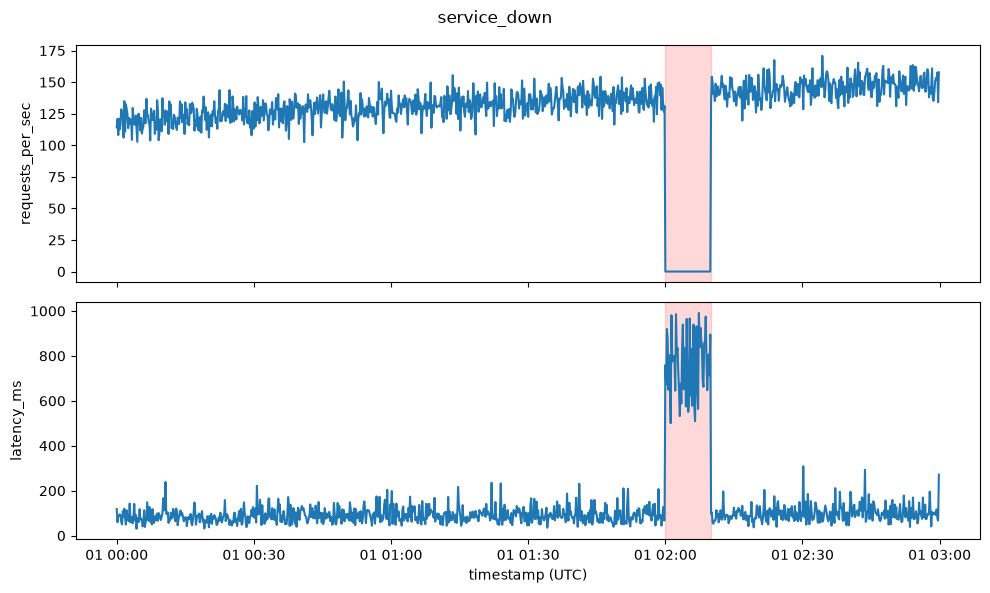

In [6]:
start_minute, window_minutes = 120, 10
df_service_down = generate(
    DURATION_MINUTES,
    scenario="service_down",
    scenario_start_minute=start_minute,
    anomaly_duration_minutes=window_minutes,
    seed=SEED,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, column in zip(axes, ["requests_per_sec", "latency_ms"]):
    ax.plot(df_service_down.index, df_service_down[column])
    ax.axvspan(
        df_service_down.index[0] + pd.Timedelta(minutes=start_minute),
        df_service_down.index[0] + pd.Timedelta(minutes=start_minute + window_minutes),
        color="red", alpha=0.15,
    )
    ax.set_ylabel(column)
axes[-1].set_xlabel("timestamp (UTC)")
fig.suptitle("service_down")
fig.tight_layout()
plt.show()
